
🔹 PROCESSING DATASET: n20
   Found 20 log files.
   ✅ Saved Average CSV: TSP_n20_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n20.csv
   ✅ Saved Plot: TSP_n20_EA_dual_bound_Parsing_Expansion_Limit_Results\Plot_n20.png


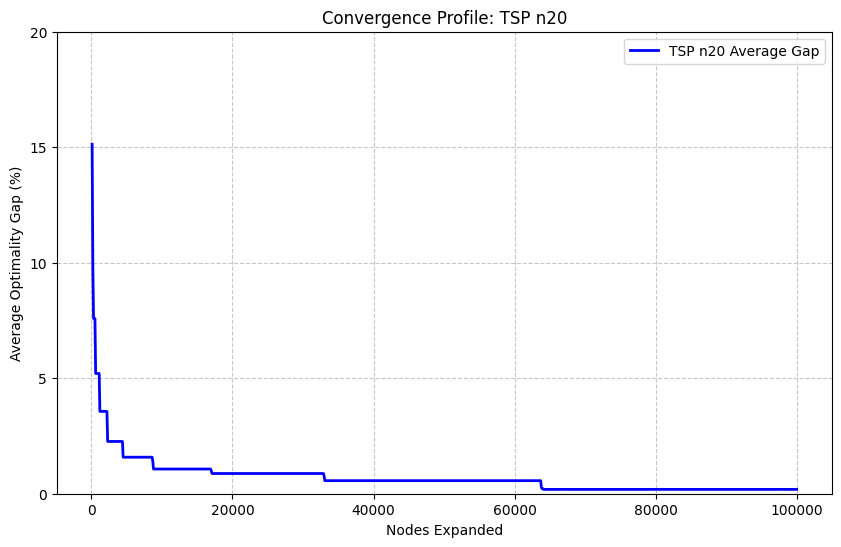


🔹 PROCESSING DATASET: n50
   Found 20 log files.
   ✅ Saved Average CSV: TSP_n50_EA_dual_bound_Parsing_Expansion_Limit_Results\EA_dual_bound_average_Gap_Profile_n50.csv
   ✅ Saved Plot: TSP_n50_EA_dual_bound_Parsing_Expansion_Limit_Results\Plot_n50.png


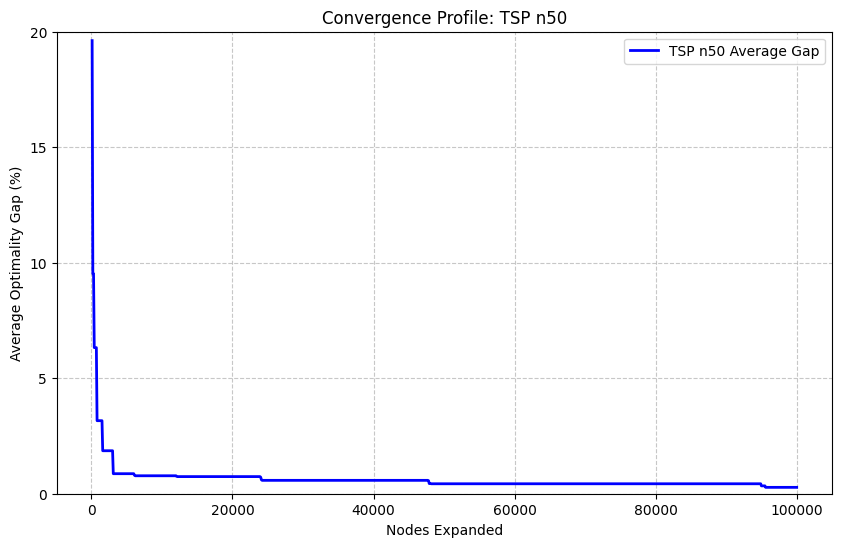

In [4]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
# 1. PATHS FOR N=20
DIR_LOGS_N20 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_time_limit\TSP_EA_dual_bound_solver_logs_n20"
REF_CSV_N20  = "TSP_single_dual_bound_20_cus_selected_results_1800s_lim.csv"
OUT_DIR_N20  = "TSP_n20_EA_dual_bound_Parsing_Expansion_Limit_Results"

# 2. PATHS FOR N=50
DIR_LOGS_N50 = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Solve_TSP_time_limit\TSP_EA_dual_bound_solver_logs_n50"
REF_CSV_N50  = "TSP_single_dual_bound_50_cus_selected_results_1800s_lim.csv"
OUT_DIR_N50  = "TSP_n50_EA_dual_bound_Parsing_Expansion_Limit_Results"

# 3. SETTINGS
NODE_LIMIT = 100_000  # The expansion limit for the X-axis

# ==========================================
# 🧩 HELPER FUNCTIONS
# ==========================================
def parse_solver_log(file_path, node_limit):
    """
    Reads log line-by-line. Tracks current best cost.
    Records history points for BOTH 'New primal bound' and 'Searched with beam size'.
    Stops reading immediately when expansion exceeds node_limit.
    """
    history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                
                # 1. Check for New Primal Bound (Update State)
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    
                    current_best_cost = cost # Update state
                    history.append((expanded, cost))
                    
                    if expanded > node_limit:
                        break # Stop reading
                    continue # Skip checking other regex for this line

                # 2. Check for Beam Search Progress (Record State)
                # This confirms the solver reached this node count with the *current* best cost
                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    
                    # Record the current state at this expansion point
                    history.append((expanded, current_best_cost))
                    
                    if expanded > node_limit:
                        break # Stop reading
                        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    
    # Sort to ensure timeline correctness
    history.sort(key=lambda x: x[0])
    return history

def calculate_dense_gaps(history, optimal_cost, limit):
    """
    Generates a dense gap array up to the limit.
    Because 'history' now contains the 'heartbeat' of the solver (beam expansions),
    the logic here simply carries the last seen cost forward.
    """
    sample_rate = 100 
    max_steps = limit // sample_rate
    dense_gaps = np.full(max_steps, np.nan)

    if not history: 
        return dense_gaps, sample_rate 

    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        # Advance through history to find the most recent update
        # associated with the current node count (or before it)
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            # We take the cost from history. 
            # Note: history now contains both "new bounds" and "checkpoints".
            # We always take the min to be safe, though log order usually implies last is current.
            val = history[hist_idx][1]
            if val < current_cost:
                current_cost = val
            elif val == float('inf'):
                pass # Keep existing
            else:
                # If history has a higher cost (unlikely if sorted), ignore.
                # Just stick to current_cost which is monotonic decreasing.
                pass
                
            hist_idx += 1
            
        # Calculate gap
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

def process_dataset(log_dir, ref_csv_path, output_dir, label_n):
    print(f"\n🔹 PROCESSING DATASET: {label_n}")
    
    if not os.path.exists(ref_csv_path):
        print(f"❌ Reference CSV not found: {ref_csv_path}")
        return None
    if not os.path.exists(log_dir):
        print(f"❌ Log directory not found: {log_dir}")
        return None

    os.makedirs(output_dir, exist_ok=True)
    
    # Load Reference Data
    df_ref = pd.read_csv(ref_csv_path)
    if 'Best Known Cost' in df_ref.columns:
        cost_col = 'Best Known Cost'
    elif 'Cost' in df_ref.columns:
        cost_col = 'Cost'
    else:
        print("❌ Could not find 'Cost' column.")
        return None
    
    # Map: "instance_name" -> optimal_cost
    bks_map = {
        str(row['Instance']).replace(".txt", "").replace(".vrp", "").strip(): float(row[cost_col]) 
        for _, row in df_ref.iterrows()
    }

    log_files = glob.glob(os.path.join(log_dir, "*.txt"))
    print(f"   Found {len(log_files)} log files.")
    
    all_dense_gaps = []

    for log_path in log_files:
        filename = os.path.basename(log_path)
        name_clean = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        if name_clean not in bks_map:
            continue

        opt_cost = bks_map[name_clean]
        
        # 1. Parse (Corrected Logic)
        history = parse_solver_log(log_path, NODE_LIMIT)
        
        if history:
            # 2. Calculate Gaps
            dense_gaps, step_size = calculate_dense_gaps(history, opt_cost, NODE_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # 3. Save Individual Profile
            df_ind = pd.DataFrame({
                'Node_Count': np.arange(step_size, NODE_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            df_ind.to_csv(os.path.join(output_dir, f"gap_{name_clean}.csv"), index=False)

    # 4. Aggregate
    if all_dense_gaps:
        gap_matrix = np.vstack(all_dense_gaps)
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
            
        x_axis = np.arange(100, NODE_LIMIT + 1, 100)
        df_avg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        avg_path = os.path.join(output_dir, f"EA_dual_bound_average_Gap_Profile_{label_n}.csv")
        df_avg.to_csv(avg_path, index=False)
        print(f"   ✅ Saved Average CSV: {avg_path}")
        return avg_path
    else:
        print("   ⚠️ No valid data extracted.")
        return None

def plot_profile(csv_path, label_n, output_dir):
    if not csv_path or not os.path.exists(csv_path): return

    df = pd.read_csv(csv_path)
    x = df['Node_Count']
    y = df['Average_Gap_Percent']

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label=f'TSP {label_n} Average Gap', color='blue', linewidth=2)
    
    # 5-Step Y-Axis
    max_y = np.nanmax(y) if len(y) > 0 else 100
    if pd.isna(max_y): max_y = 100
    upper_limit = math.ceil(max_y / 5) * 5
    plt.yticks(np.arange(0, upper_limit + 5, 5))
    plt.ylim(0, upper_limit)

    plt.xlabel('Nodes Expanded')
    plt.ylabel('Average Optimality Gap (%)')
    plt.title(f'Convergence Profile: TSP {label_n}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plot_path = os.path.join(output_dir, f"Plot_{label_n}.png")
    plt.savefig(plot_path, dpi=300)
    print(f"   ✅ Saved Plot: {plot_path}")
    plt.show()

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Process N=20
    avg_csv_n20 = process_dataset(DIR_LOGS_N20, REF_CSV_N20, OUT_DIR_N20, "n20")
    plot_profile(avg_csv_n20, "n20", OUT_DIR_N20)

    # Process N=50
    avg_csv_n50 = process_dataset(DIR_LOGS_N50, REF_CSV_N50, OUT_DIR_N50, "n50")
    plot_profile(avg_csv_n50, "n50", OUT_DIR_N50)